# Phase 4: Feature Engineering

This notebook focuses on transforming cleaned text into numerical representations: 
1. **TF-IDF (Sparse)**: For keyword-based classification.
2. **Sentence Embeddings (Dense)**: For semantic matching.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# Local imports
sys.path.append("../")
from src.features.embeddings import load_embedding_model, generate_embeddings, save_embeddings

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Processed Data

In [2]:
df_resumes = pd.read_csv("../data/processed/resumes_cleaned.csv")
df_jobs = pd.read_csv("../data/processed/jobs_cleaned.csv")

print(f"Loaded {len(df_resumes)} cleaned resumes.")
print(f"Loaded {len(df_jobs)} cleaned job descriptions.")

Loaded 2483 cleaned resumes.
Loaded 10000 cleaned job descriptions.


## 2. TF-IDF Vectorization
We use unigrams and bigrams with a limit of 10,000 features.

In [3]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit on resumes (our primary classification target)
X_tfidf_resumes = tfidf.fit_transform(df_resumes['cleaned_text'].fillna(''))
X_tfidf_jobs = tfidf.transform(df_jobs['combined_context'].fillna(''))

print(f"TF-IDF Matrix Shape (Resumes): {X_tfidf_resumes.shape}")
print(f"TF-IDF Matrix Shape (Jobs): {X_tfidf_jobs.shape}")

# Save Vectorizer
os.makedirs("../models", exist_ok=True)
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
print("tfidf_vectorizer.pkl saved to models/")

TF-IDF Matrix Shape (Resumes): (2483, 10000)
TF-IDF Matrix Shape (Jobs): (10000, 10000)
tfidf_vectorizer.pkl saved to models/


## 3. Dense Embeddings (Sentence Transformers)
Using the `all-MiniLM-L6-v2` model for lightweight but powerful semantic vectors.

In [4]:
model = load_embedding_model()

print("Generating Resume Embeddings...")
resume_embeddings = generate_embeddings(df_resumes['cleaned_text'].fillna('').tolist(), model=model)

print("Generating Job Embeddings...")
job_embeddings = generate_embeddings(df_jobs['combined_context'].fillna('').tolist(), model=model)

# Save to disk
os.makedirs("../data/embeddings", exist_ok=True)
save_embeddings(resume_embeddings, "../data/embeddings/resume_embeddings.npy")
save_embeddings(job_embeddings, "../data/embeddings/job_embeddings.npy")

[...] Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[✓] Model loaded. Max sequence length: 256
Generating Resume Embeddings...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

[✓] Generated 2483 embeddings of dimension 384
Generating Job Embeddings...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

[✓] Generated 10000 embeddings of dimension 384
[✓] Embeddings saved to ../data/embeddings/resume_embeddings.npy
[✓] Embeddings saved to ../data/embeddings/job_embeddings.npy


## 4. Dimensionality Reduction & Visualization (t-SNE)
Visualizing how different resume categories cluster in the embedding space.

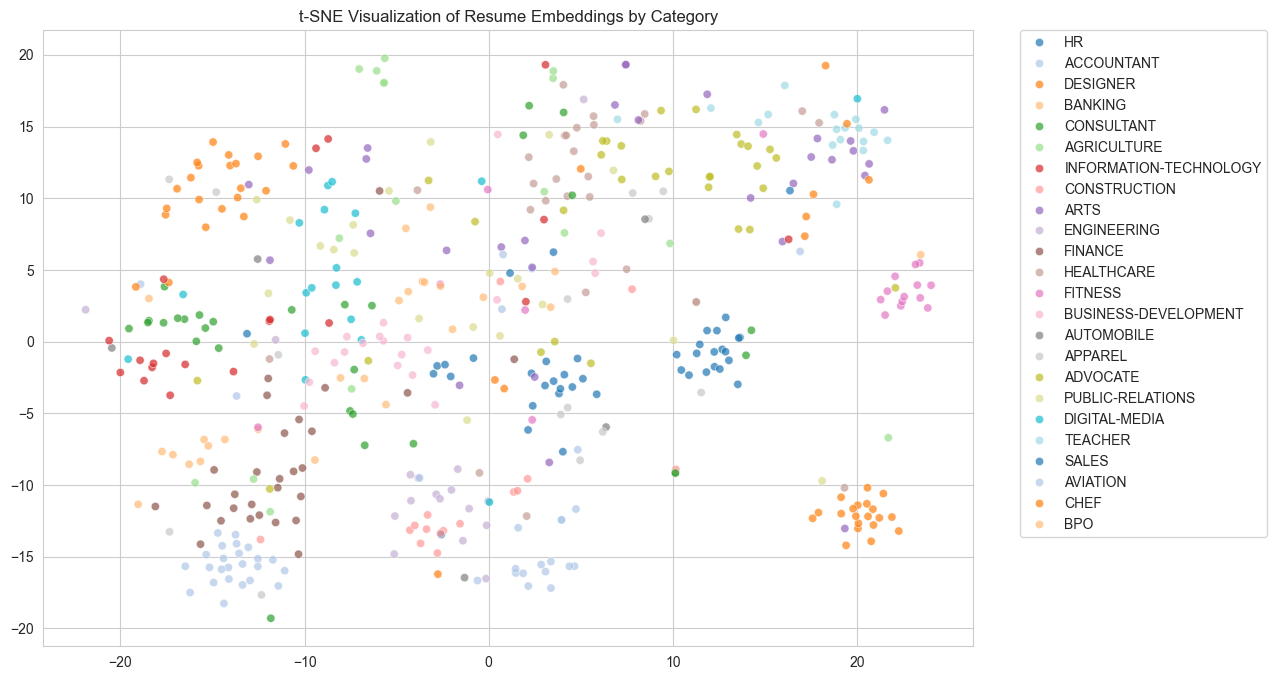

In [5]:
# Sample for visualization (t-SNE is slow)
n_samples = 500
indices = np.random.choice(len(resume_embeddings), n_samples, replace=False)
sample_embeddings = resume_embeddings[indices]
sample_labels = df_resumes.iloc[indices]['Category']

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(sample_embeddings)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=vis_dims[:,0], y=vis_dims[:,1], hue=sample_labels, palette='tab20', alpha=0.7)
plt.title("t-SNE Visualization of Resume Embeddings by Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()